# TEA-seq Model Comparison (CellTypist labels)

This notebook:
1. Loads the TEA-seq dataset annotated with CellTypist.
2. Loads all trained topic models under `/data/omics_topic_models/teaseq`.
3. Selects the best model by NMI/ARI against CellTypist labels.
4. Loads MultiVI and MOFA+ baselines.
5. Evaluates kNN (k=5) cell-type prediction for each embedding.


In [1]:
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import muon as mu
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import scipy.sparse as sp
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings("ignore")

DATA_PATH = "/data/GSE158013/GSM5123951_celltypist.h5mu"
MODELS_DIR = Path("/data/omics_topic_models/teaseq")
BASELINES_DIR = Path("/data/omics_topic_models/teaseq/baselines")
MULTIVI_LATENT_PATH = BASELINES_DIR / "latent_multivi.npy"
MULTIVI_LINEAR_LATENT_PATH = BASELINES_DIR / "latent_multivi_linear.npy"
LDA_LATENT_PATHS = {
    "AmortizedLDA (RNA)": BASELINES_DIR / "latent_amortized_lda_rna.npy",
    "AmortizedLDA (ATAC)": BASELINES_DIR / "latent_amortized_lda_atac.npy",
    "AmortizedLDA (Protein)": BASELINES_DIR / "latent_amortized_lda_prot.npy",
}
MOFA_PATH = BASELINES_DIR / "mdata_mofa.h5mu"


/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load TEA-seq data (annotated with CellTypist)


In [2]:
from omics_topic import MultimodalAmortizedLDA


def ensure_counts_layer(adata):
    if "counts" not in adata.layers:
        adata.layers["counts"] = adata.X.copy()


def binarize_atac(adata_atac):
    X = adata_atac.layers["counts"]
    if sp.issparse(X):
        X = X.tocsr(copy=True)
        X.data = np.ones_like(X.data)
        X.eliminate_zeros()
    else:
        X = (X > 0).astype(np.int8)
    adata_atac.layers["counts"] = X


def load_data():
    mdata = mu.read_h5mu(DATA_PATH)

    ensure_counts_layer(mdata.mod["rna"])
    ensure_counts_layer(mdata.mod["atac"])
    ensure_counts_layer(mdata.mod["prot"])

    # Binarize ATAC counts
    binarize_atac(mdata.mod["atac"])

    # Filter to highly variable genes/peaks (same as training)
    sc.pp.highly_variable_genes(
        mdata.mod["rna"], n_top_genes=2000, flavor="seurat_v3", layer="counts"
    )
    mdata.mod["rna"] = mdata.mod["rna"][:, mdata.mod["rna"].var["highly_variable"]].copy()

    sc.pp.highly_variable_genes(
        mdata.mod["atac"], n_top_genes=10000, flavor="seurat_v3", layer="counts"
    )
    mdata.mod["atac"] = mdata.mod["atac"][:, mdata.mod["atac"].var["highly_variable"]].copy()

    mdata.update()

    print(f"RNA: {mdata.mod['rna'].shape}")
    print(f"ATAC: {mdata.mod['atac'].shape}")
    print(f"Protein: {mdata.mod['prot'].shape}")

    return mdata


def find_true_umap(mdata):
    if "X_umap" in mdata.obsm:
        return mdata.obsm["X_umap"], "mdata"
    for mod_name in ("rna", "atac", "prot"):
        if mod_name in mdata.mod and "X_umap" in mdata.mod[mod_name].obsm:
            return mdata.mod[mod_name].obsm["X_umap"], mod_name
    return None, None


mdata = load_data()

true_umap, true_umap_source = find_true_umap(mdata)
if true_umap is not None:
    print(f"Found true UMAP coordinates in {true_umap_source}")
else:
    print("No precomputed UMAP coordinates found; using representation-derived UMAP.")


if "celltypist_label" not in mdata.mod["rna"].obs.columns:
    raise ValueError("CellTypist labels not found in RNA obs. Run annotation first.")

cell_types = mdata.mod["rna"].obs["celltypist_label"].astype(str).values
print(f"Cell types: {len(np.unique(cell_types))} unique labels")
print(pd.Series(cell_types).value_counts())


RNA: (5805, 2000)
ATAC: (5805, 10000)
Protein: (5805, 46)
Found true UMAP coordinates in mdata
Cell types: 10 unique labels
Tcm/Naive helper T cells       3059
Naive B cells                  1050
Tem/Trm cytotoxic T cells       617
CD16+ NK cells                  387
Classical monocytes             263
MAIT cells                      166
Memory B cells                  148
Tem/Effector helper T cells      77
Non-classical monocytes          26
HSC/MPP                          12
Name: count, dtype: int64


## 2. Load all trained topic models and compute metrics


In [3]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
import re


def parse_model_config(dirname):
    config = {}
    if "horseshoe" in dirname:
        config["feature_prior_type"] = "horseshoe"
    else:
        config["feature_prior_type"] = "logistic_normal"

    if "weight_cell" in dirname:
        config["weight_mode"] = "cell"
    elif "weight_universal" in dirname:
        config["weight_mode"] = "universal"
    else:
        config["weight_mode"] = "equal"

    if "learnable_disp_global" in dirname:
        config["dispersion"] = "learnable_global"
    elif "learnable_disp_pergene" in dirname:
        config["dispersion"] = "learnable_pergene"
    else:
        config["dispersion"] = "fixed"

    match = re.search(r"likewt_(inverse_features|sqrt_inverse_features)(?:_(mean|median|max))?", dirname)
    if match:
        config["likelihood_weight_mode"] = match.group(1)
        config["likelihood_weight_ref"] = match.group(2) or "mean"
    else:
        config["likelihood_weight_mode"] = "none"
        config["likelihood_weight_ref"] = "mean"

    return config


def compute_cell_type_correlation(theta, labels):
    topic_assignments = np.argmax(theta, axis=1)
    le = LabelEncoder()
    labels_encoded = le.fit_transform(labels)
    ari = adjusted_rand_score(labels_encoded, topic_assignments)
    nmi = normalized_mutual_info_score(labels_encoded, topic_assignments)
    return {"ARI": ari, "NMI": nmi}


def evaluate_knn_classification(X, y, k=5, test_size=0.2, random_state=42):
    """Evaluate kNN classification accuracy."""
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    knn = KNeighborsClassifier(n_neighbors=k, metric="cosine")
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_val)
    return {
        "accuracy": accuracy_score(y_val, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_val, y_pred),
    }


model_dirs = sorted(
    [d for d in MODELS_DIR.iterdir() if d.is_dir() and d.name.startswith("prior_")]
)
print(f"Found {len(model_dirs)} candidate model dirs")

# Prepare data for loading
mdata_setup, modality_names, feat_counts = MultimodalAmortizedLDA.setup_mudata(
    mdata,
    modality_order=["rna", "atac", "prot"],
    layers="counts",
)
adata_flat = mdata.uns["_flattened_ann_data"]

cell_types_array = cell_types

results = []
for model_dir in model_dirs:
    model_path = model_dir / "model"
    if not model_path.exists():
        continue

    print(f"Loading {model_dir.name}...")
    try:
        model = MultimodalAmortizedLDA.load(str(model_path), adata=adata_flat)
        theta = model.get_latent_representation(batch_size=mdata.n_obs)
        theta_array = np.asarray(theta)

        config = parse_model_config(model_dir.name)
        diversity = model.get_topic_diversity()
        diversity_rna = model.get_topic_diversity(modality="rna")
        diversity_atac = model.get_topic_diversity(modality="atac")
        diversity_prot = model.get_topic_diversity(modality="prot")

        corr_metrics = compute_cell_type_correlation(theta_array, cell_types)
        
        # Compute kNN classification accuracy
        knn_metrics = evaluate_knn_classification(theta_array - 1, cell_types_array, k=5)

        result = {
            "model_name": model_dir.name,
            **config,
            "diversity": diversity,
            "diversity_rna": diversity_rna,
            "diversity_atac": diversity_atac,
            "diversity_prot": diversity_prot,
            "ARI": corr_metrics["ARI"],
            "NMI": corr_metrics["NMI"],
            "knn_accuracy": knn_metrics["accuracy"],
            "knn_balanced_accuracy": knn_metrics["balanced_accuracy"],
            "theta": theta_array,
        }
        results.append(result)

        print(
            f"  Diversity: {diversity:.4f}, "
            f"kNN Acc: {knn_metrics['accuracy']:.4f}, "
            f"kNN Balanced: {knn_metrics['balanced_accuracy']:.4f}"
        )
    except Exception as e:
        print(f"  Error loading model: {e}")

print(f"Successfully loaded {len(results)} models")

Found 20 candidate model dirs
Loading prior_horseshoe_weight_cell...
INFO     File /data/omics_topic_models/teaseq/prior_horseshoe_weight_cell/model/model.pt already downloaded        


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA A100-PCIE-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 1/1000:   0%|          | 1/1000 [00:00<03:54,  4.26it/s, v_num=1]

`Trainer.fit` stopped: `max_steps=1` reached.


Epoch 1/1000:   0%|          | 1/1000 [00:00<04:03,  4.10it/s, v_num=1]
  Diversity: 0.4336, kNN Acc: 0.8941, kNN Balanced: 0.7127
Loading prior_horseshoe_weight_cell_learnable_disp_global...
INFO     File /data/omics_topic_models/teaseq/prior_horseshoe_weight_cell_learnable_disp_global/model/model.pt     
         already downloaded                                                                                        


...

Epoch 1/1000:   0%|          | 1/1000 [00:00<01:12, 13.79it/s, v_num=1]
  Diversity: 0.5386, kNN Acc: 0.8984, kNN Balanced: 0.6825
Loading prior_logistic_normal_weight_universal_likewt_sqrt_inverse_features...
INFO     File                                                                                                      
         /data/omics_topic_models/teaseq/prior_logistic_normal_weight_universal_likewt_sqrt_inverse_features/model/
         model.pt already downloaded                                                                               


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 1/1000:   0%|          | 1/1000 [00:00<00:52, 19.02it/s, v_num=1]

`Trainer.fit` stopped: `max_steps=1` reached.


Epoch 1/1000:   0%|          | 1/1000 [00:00<00:57, 17.28it/s, v_num=1]
  Diversity: 0.4698, kNN Acc: 0.8906, kNN Balanced: 0.7053
Successfully loaded 20 models


## 3. Select best model by kNN accuracy

In [4]:
results_display = [{k: v for k, v in r.items() if k != "theta"} for r in results]

df_results = pd.DataFrame(results_display)
if df_results.empty:
    raise ValueError("No models loaded. Check MODELS_DIR and model paths.")

# Sort by kNN balanced accuracy
_df_sorted = df_results.sort_values("knn_balanced_accuracy", ascending=False)
print("Model Comparison (sorted by kNN Balanced Accuracy):")
print(_df_sorted.to_string(index=False))

best_idx = _df_sorted["knn_balanced_accuracy"].idxmax()
best_model_name = _df_sorted.loc[best_idx, "model_name"]
best_result = next(r for r in results if r["model_name"] == best_model_name)

print(f"\nBest model: {best_model_name}")
print(f"  Feature prior: {best_result['feature_prior_type']}")
print(f"  Weight mode: {best_result['weight_mode']}")
print(f"  Dispersion: {best_result['dispersion']}")
print(f"  kNN Accuracy: {best_result['knn_accuracy']:.4f}")
print(f"  kNN Balanced Accuracy: {best_result['knn_balanced_accuracy']:.4f}")
print(f"  NMI: {best_result['NMI']:.4f}")
print(f"  ARI: {best_result['ARI']:.4f}")
print(f"  Diversity: {best_result['diversity']:.4f}")

theta_best = best_result["theta"]

Model Comparison (sorted by kNN Balanced Accuracy):
                                                         model_name feature_prior_type weight_mode        dispersion likelihood_weight_mode likelihood_weight_ref  diversity  diversity_rna  diversity_atac  diversity_prot      ARI      NMI  knn_accuracy  knn_balanced_accuracy
            prior_logistic_normal_weight_cell_learnable_disp_global    logistic_normal        cell  learnable_global                   none                  mean   0.434893       0.561090        0.118431        0.625158 0.587316 0.689222      0.906977               0.754010
           prior_logistic_normal_weight_equal_learnable_disp_global    logistic_normal       equal  learnable_global                   none                  mean   0.462424       0.610312        0.123153        0.653809 0.596362 0.692882      0.922481               0.748728
                                  prior_logistic_normal_weight_cell    logistic_normal        cell             fixed       

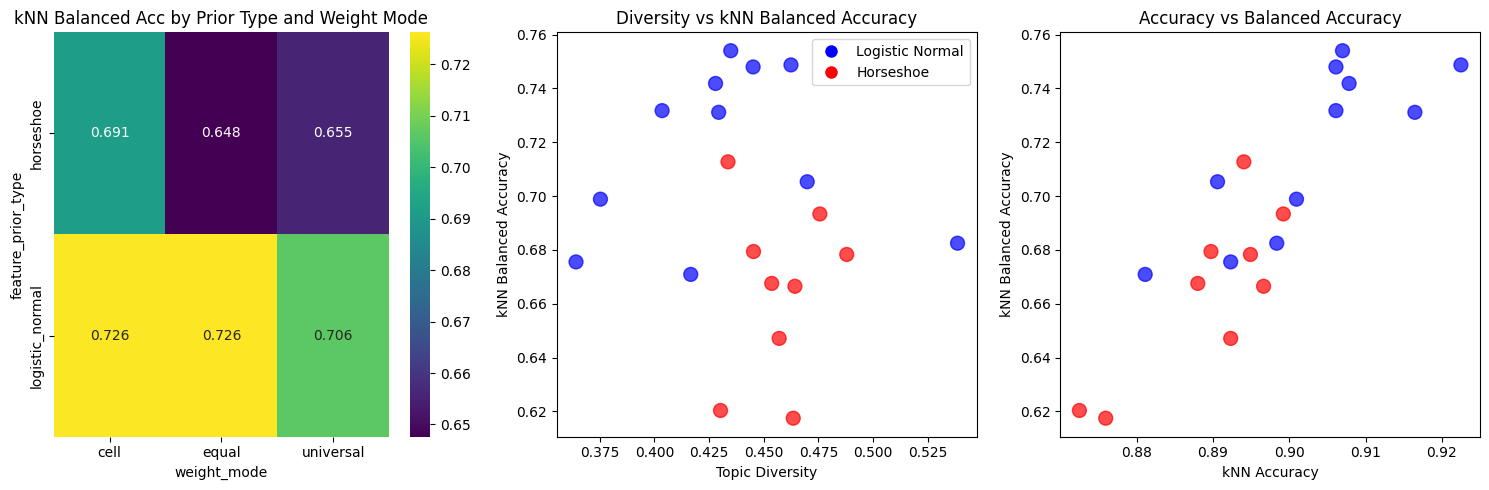

In [5]:
# Visualize results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

ax = axes[0]
df_pivot = _df_sorted.pivot_table(
    values="knn_balanced_accuracy", index="feature_prior_type", columns="weight_mode", aggfunc="mean"
)
sns.heatmap(df_pivot, annot=True, fmt=".3f", cmap="viridis", ax=ax)
ax.set_title("kNN Balanced Acc by Prior Type and Weight Mode")

ax = axes[1]
colors = _df_sorted["feature_prior_type"].map({"logistic_normal": "blue", "horseshoe": "red"})
ax.scatter(_df_sorted["diversity"], _df_sorted["knn_balanced_accuracy"], c=colors, s=100, alpha=0.7)
ax.set_xlabel("Topic Diversity")
ax.set_ylabel("kNN Balanced Accuracy")
ax.set_title("Diversity vs kNN Balanced Accuracy")
ax.legend(
    handles=[
        plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="blue", markersize=10, label="Logistic Normal"),
        plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="red", markersize=10, label="Horseshoe"),
    ]
)

ax = axes[2]
ax.scatter(_df_sorted["knn_accuracy"], _df_sorted["knn_balanced_accuracy"], c=colors, s=100, alpha=0.7)
ax.set_xlabel("kNN Accuracy")
ax.set_ylabel("kNN Balanced Accuracy")
ax.set_title("Accuracy vs Balanced Accuracy")

plt.tight_layout()
plt.show()

## 4. Load MultiVI, Linear MultiVI, AmortizedLDA, and MOFA+ baselines


In [6]:
latent_multivi = None
if MULTIVI_LATENT_PATH.exists():
    latent_multivi = np.load(MULTIVI_LATENT_PATH)
    print(f"Loaded MultiVI latent: {latent_multivi.shape}")
else:
    print(f"MultiVI latent file not found: {MULTIVI_LATENT_PATH}")

latent_multivi_linear = None
if MULTIVI_LINEAR_LATENT_PATH.exists():
    latent_multivi_linear = np.load(MULTIVI_LINEAR_LATENT_PATH)
    print(f"Loaded MultiVI Linear latent: {latent_multivi_linear.shape}")
else:
    print(f"MultiVI Linear latent file not found: {MULTIVI_LINEAR_LATENT_PATH}")

latent_lda = {}
for name, path in LDA_LATENT_PATHS.items():
    if path.exists():
        latent_lda[name] = np.load(path)
        print(f"Loaded {name} latent: {latent_lda[name].shape}")
    else:
        print(f"{name} latent not found: {path}")

latent_mofa = None
if MOFA_PATH.exists():
    mdata_mofa = mu.read_h5mu(MOFA_PATH)
    latent_mofa = np.asarray(mdata_mofa.obsm["X_mofa"])
    print(f"Loaded MOFA+ latent: {latent_mofa.shape}")
else:
    print(f"MOFA+ MuData not found: {MOFA_PATH}")


Loaded MultiVI latent: (5805, 10)
Loaded MultiVI Linear latent: (5805, 10)
Loaded AmortizedLDA (RNA) latent: (5805, 10)
Loaded AmortizedLDA (ATAC) latent: (5805, 10)
Loaded AmortizedLDA (Protein) latent: (5805, 10)
Loaded MOFA+ latent: (5805, 10)


## 5. kNN classification comparison


In [7]:
# Collect kNN results - only the best topic model + baselines
knn_results = {}

# Best topic model (already computed)
knn_results["Omics-Topic"] = {
    "accuracy": best_result["knn_accuracy"],
    "balanced_accuracy": best_result["knn_balanced_accuracy"],
}
print(f"Best Topic Model: {best_model_name}")
print(f"  Accuracy: {knn_results['Omics-Topic']['accuracy']:.4f}")
print(f"  Balanced Accuracy: {knn_results['Omics-Topic']['balanced_accuracy']:.4f}")

if latent_multivi is not None:
    print("\nEvaluating MultiVI...")
    knn_results["MultiVI"] = evaluate_knn_classification(latent_multivi, cell_types_array, k=5)
    print(f"  Accuracy: {knn_results['MultiVI']['accuracy']:.4f}")
    print(f"  Balanced Accuracy: {knn_results['MultiVI']['balanced_accuracy']:.4f}")

if latent_multivi_linear is not None:
    print("\nEvaluating MultiVI Linear...")
    knn_results["MultiVI Linear"] = evaluate_knn_classification(latent_multivi_linear, cell_types_array, k=5)
    print(f"  Accuracy: {knn_results['MultiVI Linear']['accuracy']:.4f}")
    print(f"  Balanced Accuracy: {knn_results['MultiVI Linear']['balanced_accuracy']:.4f}")

if latent_mofa is not None:
    print("\nEvaluating MOFA+...")
    knn_results["MOFA+"] = evaluate_knn_classification(latent_mofa, cell_types_array, k=5)
    print(f"  Accuracy: {knn_results['MOFA+']['accuracy']:.4f}")
    print(f"  Balanced Accuracy: {knn_results['MOFA+']['balanced_accuracy']:.4f}")

for name, latent in latent_lda.items():
    print(f"\nEvaluating {name}...")
    knn_results[name] = evaluate_knn_classification(latent, cell_types_array, k=5)
    print(f"  Accuracy: {knn_results[name]['accuracy']:.4f}")
    print(f"  Balanced Accuracy: {knn_results[name]['balanced_accuracy']:.4f}")

Best Topic Model: prior_logistic_normal_weight_cell_learnable_disp_global
  Accuracy: 0.9070
  Balanced Accuracy: 0.7540

Evaluating MultiVI...
  Accuracy: 0.9259
  Balanced Accuracy: 0.8509

Evaluating MultiVI Linear...
  Accuracy: 0.8923
  Balanced Accuracy: 0.7092

Evaluating MOFA+...
  Accuracy: 0.9139
  Balanced Accuracy: 0.7781

Evaluating AmortizedLDA (RNA)...
  Accuracy: 0.8458
  Balanced Accuracy: 0.6423

Evaluating AmortizedLDA (ATAC)...
  Accuracy: 0.7812
  Balanced Accuracy: 0.4291

Evaluating AmortizedLDA (Protein)...
  Accuracy: 0.9087
  Balanced Accuracy: 0.7335


FINAL COMPARISON: kNN (k=5) Classification Results
                 Model  Accuracy  Balanced Accuracy
               MultiVI  0.925926           0.850859
                 MOFA+  0.913867           0.778105
AmortizedLDA (Protein)  0.908699           0.733489
                  Ours  0.906977           0.754010
        MultiVI Linear  0.892334           0.709240
    AmortizedLDA (RNA)  0.845823           0.642316
   AmortizedLDA (ATAC)  0.781223           0.429124


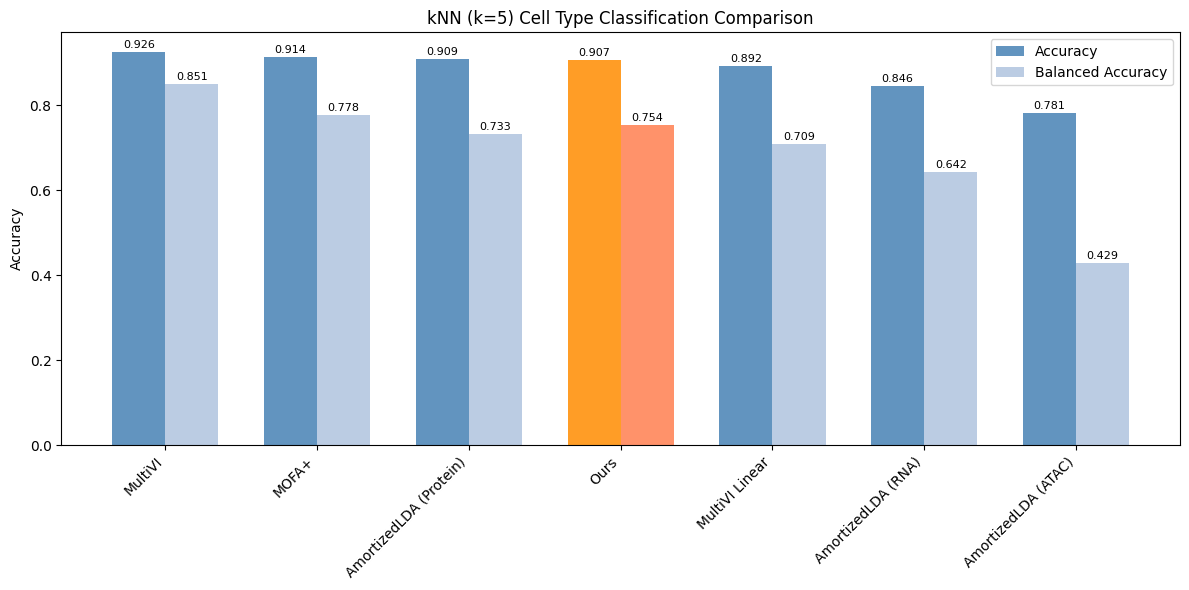


Saved kNN summary to: /data/omics_topic_models/teaseq/baselines/knn_summary.csv
Saved topic model metrics to: /data/omics_topic_models/teaseq/baselines/topic_model_metrics.csv
Saved comparison plot to: /data/omics_topic_models/teaseq/baselines/knn_comparison.png


In [8]:
summary_df = pd.DataFrame(
    {
        "Model": list(knn_results.keys()),
        "Accuracy": [r["accuracy"] for r in knn_results.values()],
        "Balanced Accuracy": [r["balanced_accuracy"] for r in knn_results.values()],
    }
).sort_values("Accuracy", ascending=False)

# Rename Omics-Topic to Ours
summary_df["Model"] = summary_df["Model"].replace("Omics-Topic", "Ours")

print("FINAL COMPARISON: kNN (k=5) Classification Results")
print(summary_df.to_string(index=False))

# Side by side bar plot
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(summary_df))
width = 0.35

colors_acc = ["darkorange" if m == "Ours" else "steelblue" for m in summary_df["Model"]]
colors_bal = ["coral" if m == "Ours" else "lightsteelblue" for m in summary_df["Model"]]

bars1 = ax.bar(x - width/2, summary_df["Accuracy"], width, label="Accuracy", color=colors_acc, alpha=0.85)
bars2 = ax.bar(x + width/2, summary_df["Balanced Accuracy"], width, label="Balanced Accuracy", color=colors_bal, alpha=0.85)

ax.set_ylabel("Accuracy")
ax.set_title("kNN (k=5) Cell Type Classification Comparison")
ax.set_xticks(x)
ax.set_xticklabels(summary_df["Model"], rotation=45, ha="right")
ax.legend()

for bar, value in zip(bars1, summary_df["Accuracy"]):
    ax.text(bar.get_x() + bar.get_width()/2, value + 0.005, f"{value:.3f}", ha="center", va="bottom", fontsize=8)
for bar, value in zip(bars2, summary_df["Balanced Accuracy"]):
    ax.text(bar.get_x() + bar.get_width()/2, value + 0.005, f"{value:.3f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()

BASELINES_DIR.mkdir(parents=True, exist_ok=True)
summary_path = BASELINES_DIR / "knn_summary.csv"
summary_df.to_csv(summary_path, index=False)
topic_metrics_path = BASELINES_DIR / "topic_model_metrics.csv"
_df_sorted.to_csv(topic_metrics_path, index=False)
plot_path = BASELINES_DIR / "knn_comparison.png"
fig.savefig(plot_path, dpi=200)
plt.show()
print(f"\nSaved kNN summary to: {summary_path}")
print(f"Saved topic model metrics to: {topic_metrics_path}")
print(f"Saved comparison plot to: {plot_path}")



## 6. UMAPs by representation (Leiden + Cell Type)



UMAPs for topic model (best)...


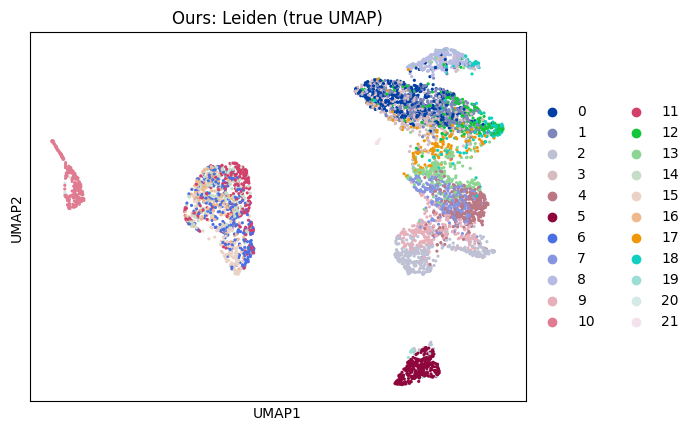

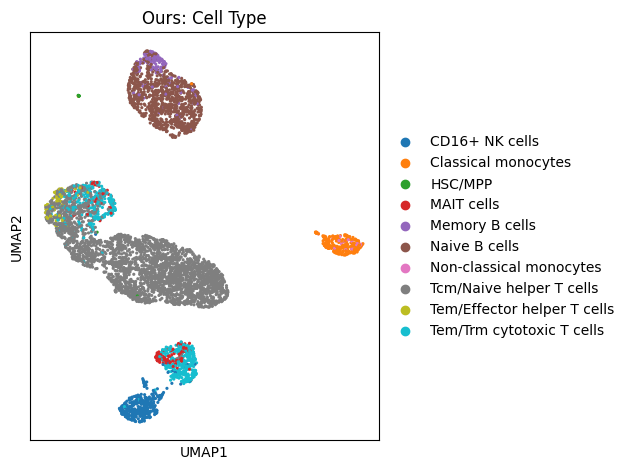


UMAPs for MultiVI...


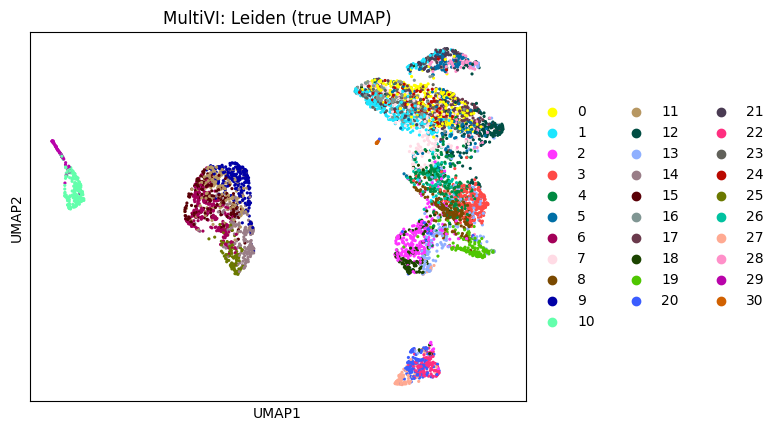

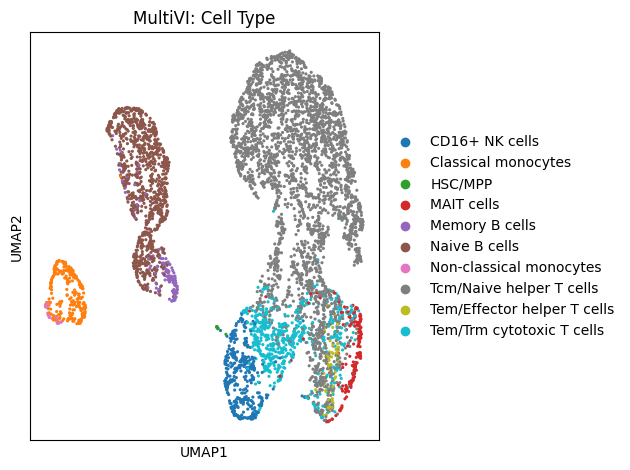


UMAPs for MultiVI Linear...


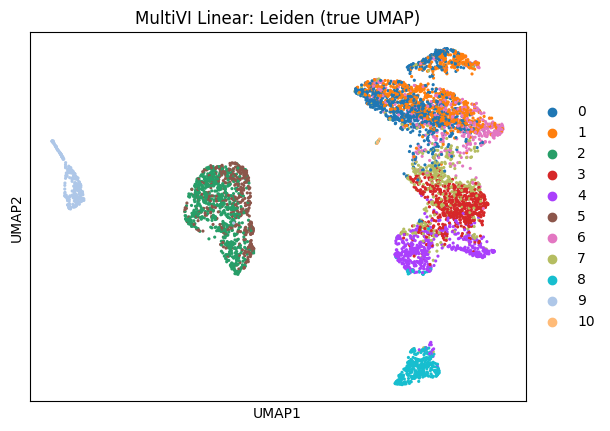

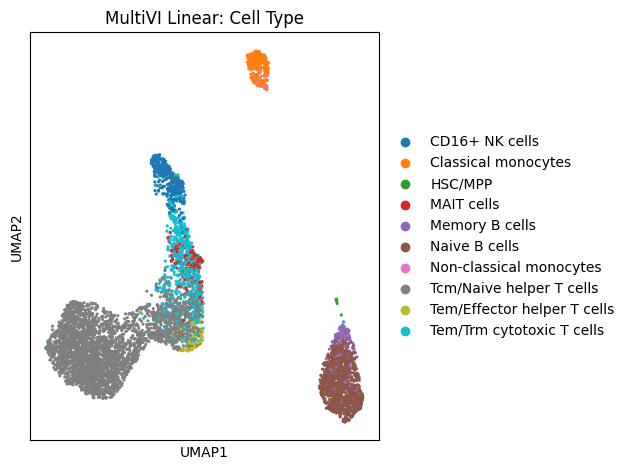


UMAPs for MOFA+...


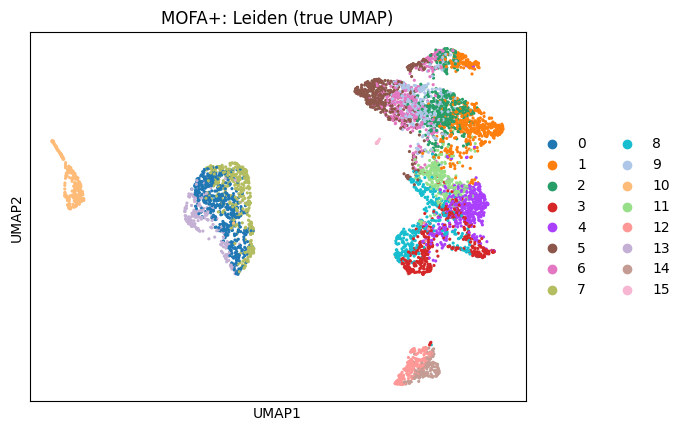

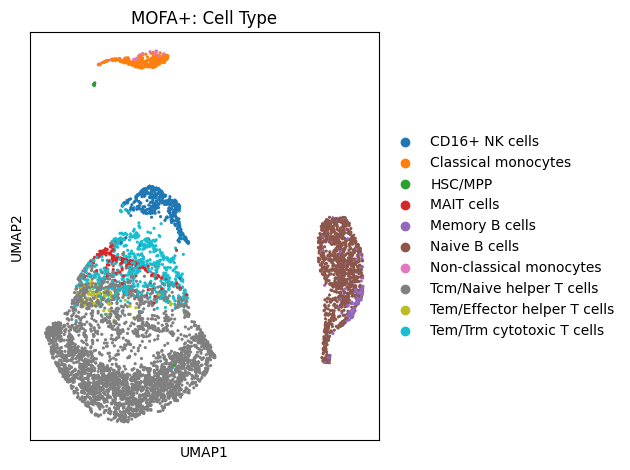


UMAPs for AmortizedLDA (RNA)...


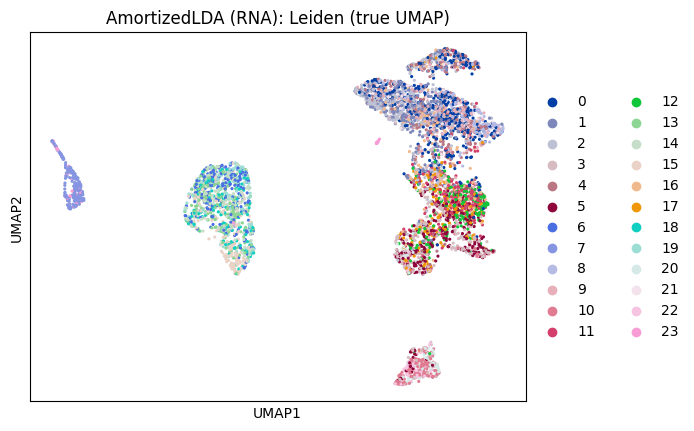

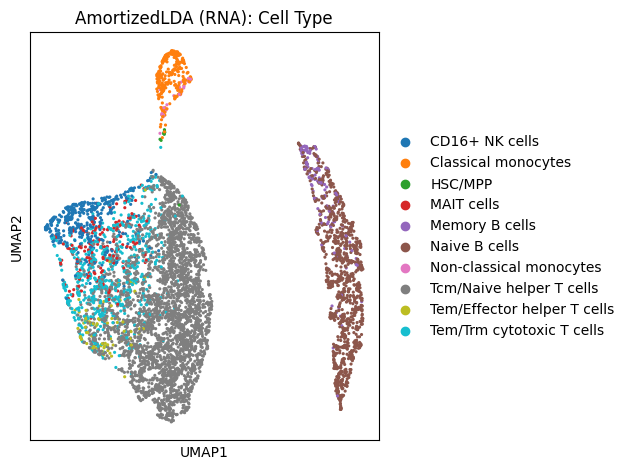


UMAPs for AmortizedLDA (ATAC)...


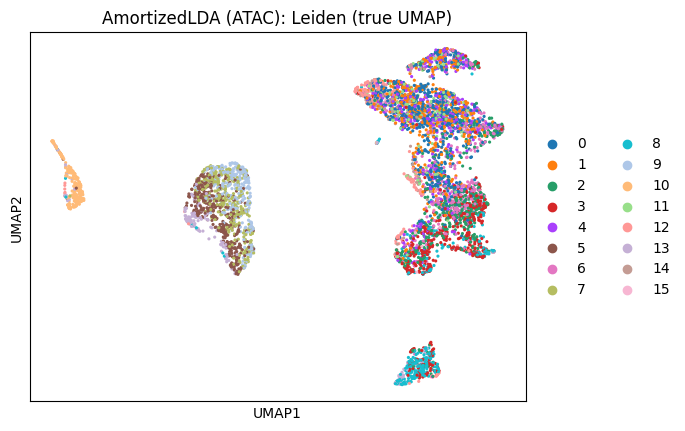

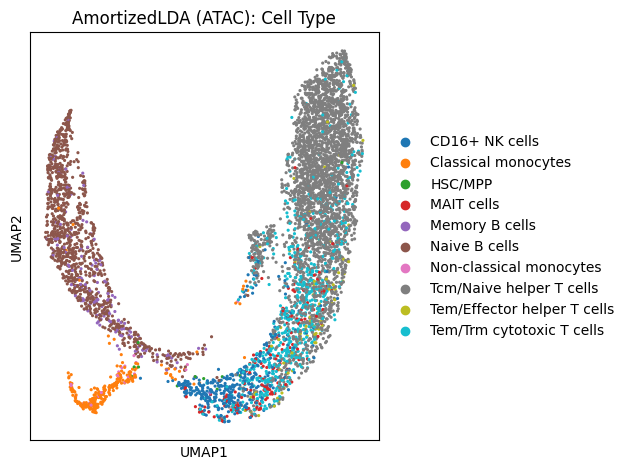


UMAPs for AmortizedLDA (Protein)...


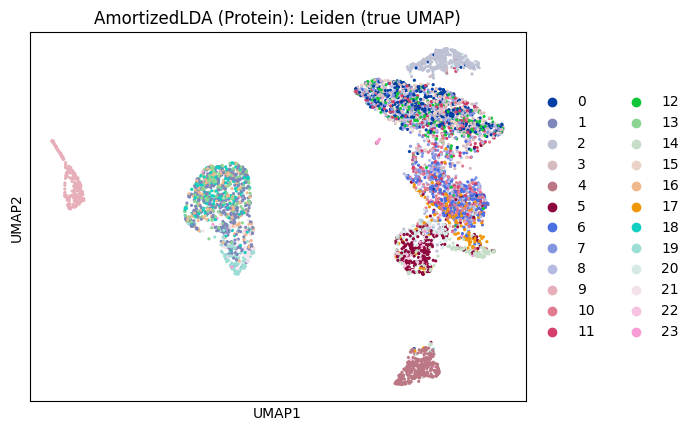

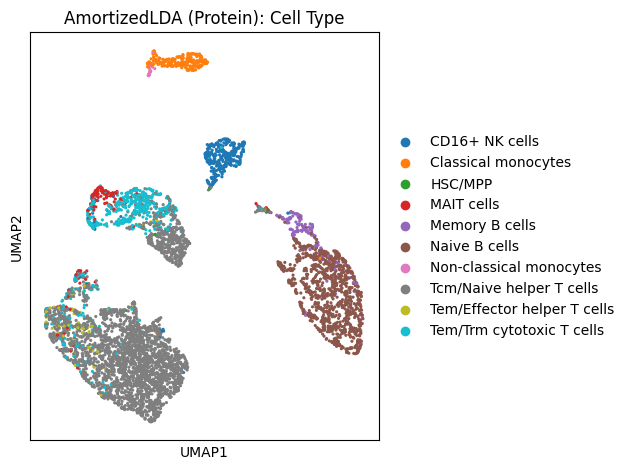

In [9]:
import anndata as ad

def plot_umap_for_rep(X, labels, title_prefix, n_neighbors=15, min_dist=0.3, true_umap=None):
    adata = ad.AnnData(np.asarray(X))
    adata.obs["cell_type"] = pd.Categorical(labels)

    sc.pp.neighbors(adata, use_rep="X", n_neighbors=n_neighbors, metric="cosine")
    sc.tl.umap(adata, min_dist=min_dist)
    sc.tl.leiden(adata, key_added="leiden")

    rep_umap = adata.obsm.get("X_umap").copy()
    use_true = (
        true_umap is not None
        and np.asarray(true_umap).shape[0] == adata.n_obs
        and np.asarray(true_umap).shape[1] == rep_umap.shape[1]
    )

    #fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    if use_true:
        adata.obsm["X_umap"] = np.asarray(true_umap)
        sc.pl.umap(
            adata,
            color="leiden",
            #ax=axes[0],
            show=False,
            title=f"{title_prefix}: Leiden (true UMAP)",
        )
        adata.obsm["X_umap"] = rep_umap
    else:
        sc.pl.umap(
            adata,
            color="leiden",
            #ax=axes[0],
            show=False,
            title=f"{title_prefix}: Leiden",
        )

    sc.pl.umap(
        adata,
        color="cell_type",
        #ax=axes[1],
        show=False,
        title=f"{title_prefix}: Cell Type",
    )
    plt.tight_layout()
    plt.show()


print("\nUMAPs for topic model (best)...")
plot_umap_for_rep(theta_best, cell_types_array, "Ours", true_umap=true_umap)

if latent_multivi is not None:
    print("\nUMAPs for MultiVI...")
    plot_umap_for_rep(latent_multivi, cell_types_array, "MultiVI", true_umap=true_umap)

if latent_multivi_linear is not None:
    print("\nUMAPs for MultiVI Linear...")
    plot_umap_for_rep(latent_multivi_linear, cell_types_array, "MultiVI Linear", true_umap=true_umap)

if latent_mofa is not None:
    print("\nUMAPs for MOFA+...")
    plot_umap_for_rep(latent_mofa, cell_types_array, "MOFA+", true_umap=true_umap)

for name, latent in latent_lda.items():
    print(f"\nUMAPs for {name}...")
    plot_umap_for_rep(latent, cell_types_array, name, true_umap=true_umap)


## Notes

- This notebook expects the CellTypist-annotated TEA-seq file:
  `/data/GSE158013/GSM5123951_celltypist.h5mu`
- Topic models are expected under `/data/omics_topic_models/teaseq` with `prior_*` directories.
- Baseline outputs are expected under `/data/omics_topic_models/teaseq/baselines`.
